In [6]:
import pandas as pd

def load_clean_design(filepath, sheet_name):
    """Loads a library design sheet and pairs the DNA and AA rows together."""
    # Read the sheet, pull just the Name (col 1) and Sequence (col 2)
    df = pd.read_excel(filepath, sheet_name=sheet_name)
    df = df.iloc[:, [1, 2]].copy()
    df.columns = ['Design_Name', 'Sequence']
    
    # Drop all empty rows
    df = df.dropna(subset=['Sequence']).reset_index(drop=True)
    
    # Because the file alternates [DNA, Amino Acid, DNA, Amino Acid], 
    # we can split them by even and odd indexes.
    dna_rows = df.iloc[0::2].reset_index(drop=True)  # Evens: 0, 2, 4...
    aa_rows = df.iloc[1::2].reset_index(drop=True)   # Odds: 1, 3, 5...
    
    # Combine them into a single clean table
    clean_df = pd.DataFrame({
        'Design_Name': dna_rows['Design_Name'],
        'DNA_Sequence': dna_rows['Sequence'],
        'AA_Sequence': aa_rows['Sequence']
    })
    
    return clean_df

# Load both sheets
heavy_design = load_clean_design('../AffMat_design.xlsx', 'Heavy Chain Design')
light_design = load_clean_design('../AffMat_design.xlsx', 'Light Chain Design')

print(f"Successfully loaded {len(heavy_design)} Heavy designs and {len(light_design)} Light designs.")
display(heavy_design, light_design)

Successfully loaded 10 Heavy designs and 11 Light designs.


,Design_Name,DNA_Sequence,AA_Sequence
0,IGHV1-18,GAGGTTCAGCTGGTGCAGTCTGGAGCTGAGGTGAAGAAGCCTGGGG...,EVQLVQSGAEVKKPGASVKVSCKASGYTFTSYGISWVRQAPGQGLE...
1,IGHV1-46,GAGGTGCAGCTGGTGCAGTCTGGGGCTGAGGTGAAGAAGCCTGGGG...,EVQLVQSGAEVKKPGASVKVSCKASGYTFTSYYMHWVRQAPGQGLE...
2,IGHV1-69,GAGGTGCAGCTGGTGCAGTCTGGGGCTGAGGTGAAGAAGCCTGGGT...,EVQLVQSGAEVKKPGSSVKVSCKASGGTFSSYAISWVRQAPGQGLE...
3,IGHV3-7,GAGGTGCAGCTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,EVQLVESGGGLVQPGGSLRLSCAASGFTFSSYWMSWVRQAPGKGLE...
4,IGHV3-15,GAGGTGCAGCTGGTGGAGTCTGGGGGAGGCTTGGTAAAGCCTGGGG...,EVQLVESGGGLVKPGGSLRLSCAASGFTFSNAWMSWVRQAPGKGLE...
5,IGHV3-23,GAGGTGCAGCTGTTGGAGTCTGGGGGAGGCTTGGTACAGCCTGGGG...,EVQLLESGGGLVQPGGSLRLSCAASGFTFSSYAMSWVRQAPGKGLE...
6,IGHV3-30,GAGGTGCAGCTGGTGGAGTCTGGGGGAGGCGTGGTCCAGCCTGGGA...,EVQLVESGGGVVQPGRSLRLSCAASGFTFSSYAMHWVRQAPGKGLE...
7,IGHV4-39,GAGCTGCAGCTGCAGGAGTCGGGCCCAGGACTGGTGAAGCCTTCGG...,ELQLQESGPGLVKPSETLSLTCTVSGGSISSSSYYWGWIRQPPGKG...
8,IGHV4-59,GAGGTGCAGCTGCAGGAGTCGGGCCCAGGACTGGTGAAGCCTTCGG...,EVQLQESGPGLVKPSETLSLTCTVSGGSISSYYWSWIRQPPGKGLE...
9,IGHV5-51,GAGGTGCAGCTGGTGCAGTCTGGAGCAGAGGTGAAAAAGCCCGGGG...,EVQLVQSGAEVKKPGESLKISCKGSGYSFTSYWIGWVRQMPGKGLE...


,Design_Name,DNA_Sequence,AA_Sequence
0,IGKV1-39,GACATCCAGATGACCCAGTCTCCATCCTCCCTGTCTGCATCTGTAG...,DIQMTQSPSSLSASVGDRVTITCRASQSISSYLNWYQQKPGKAPKL...
1,IGKV2-28,GATATTGTGATGACTCAGTCTCCACTCTCCCTGCCCGTCACCCCTG...,DIVMTQSPLSLPVTPGEPASISCRSSQSLLHSNGYNYLDWYLQKPG...
2,IGKV3-15,GAAATAGTGATGACGCAGTCTCCAGCCACCCTGTCTGTGTCTCCAG...,EIVMTQSPATLSVSPGERATLSCRASQSVSSNLAWYQQKPGQAPRL...
3,IGKV3-20,GAAATTGTGTTGACGCAGTCTCCAGGCACCCTGTCTTTGTCTCCAG...,EIVLTQSPGTLSLSPGERATLSCRASQSVSSSYLAWYQQKPGQAPR...
4,IGKV4-1,GACATCGTGATGACCCAGTCTCCAGACTCCCTGGCTGTGTCTCTGG...,DIVMTQSPDSLAVSLGERATINCKSSQSVLYSSNNKNYLAWYQQKP...
5,IGLV1-40,CAGTCTGTGCTGACGCAGCCGCCCTCAGTGTCTGGGGCCCCAGGGC...,QSVLTQPPSVSGAPGQRVTISCTGSSSNIGAGYDVHWYQQLPGTAP...
6,IGLV1-44,CAGTCTGTGCTGACTCAGCCACCCTCAGCGTCTGGGACCCCCGGGC...,QSVLTQPPSASGTPGQRVTISCSGSSSNIGSNTVNWYQQLPGTAPK...
7,IGLV1-51,CAGTCTGTGTTGACGCAGCCGCCCTCAGTGTCTGCGGCCCCAGGAC...,QSVLTQPPSVSAAPGQKVTISCSGSSSNIGNNYVSWYQQLPGTAPK...
8,IGLV2-14,CAGTCTGCCCTGACTCAGCCTGCCTCCGTGTCTGGGTCTCCTGGAC...,QSALTQPASVSGSPGQSITISCTGTSSDVGGYNYVSWYQQHPGKAP...
9,IGLV2-23,CAGTCTGCCCTGACTCAGCCTGCCTCCGTGTCTGGGTCTCCTGGAC...,QSALTQPASVSGSPGQSITISCTGTSSDVGSYNLVSWYQQHPGKAP...


In [8]:
# Load sequencing data
seq_df = pd.read_csv('../preview_1000_pairs.csv')

# Clean up whitespace just in case
heavy_designs_aa = heavy_design['AA_Sequence'].str.strip().tolist()
light_designs_aa = light_design['AA_Sequence'].str.strip().tolist()

# Function to check if ANY of our designs exist inside a given sequencing read
def check_match(seq_read, design_list):
    if not isinstance(seq_read, str):
        return False
    # Return True if any design is a substring of the read
    return any(design in seq_read for design in design_list)

# Apply the substring search to our sequencing columns
seq_df['Heavy_in_Design'] = seq_df['HAA'].apply(lambda x: check_match(x, heavy_designs_aa))
seq_df['Light_in_Design'] = seq_df['LAA'].apply(lambda x: check_match(x, light_designs_aa))
seq_df['Perfect_Pair'] = seq_df['Heavy_in_Design'] & seq_df['Light_in_Design']

# Calculate summary statistics
total_reads = seq_df['read_count'].sum()
perfect_reads = seq_df.loc[seq_df['Perfect_Pair'], 'read_count'].sum()

print("--- Library Build Summary ---")
print(f"Total Unique Pairs Sequenced: {len(seq_df)}")
print(f"Pairs with designed Heavy Chain: {seq_df['Heavy_in_Design'].sum()}")
print(f"Pairs with designed Light Chain: {seq_df['Light_in_Design'].sum()}")
print(f"Perfect Pairs (Both designed): {seq_df['Perfect_Pair'].sum()}")
if total_reads > 0:
    print(f"\nRead Count Efficiency: {(perfect_reads / total_reads) * 100:.2f}% of reads map to perfect designed pairs.")

--- Library Build Summary ---
Total Unique Pairs Sequenced: 1000
Pairs with designed Heavy Chain: 50
Pairs with designed Light Chain: 33
Perfect Pairs (Both designed): 2

Read Count Efficiency: 0.20% of reads map to perfect designed pairs.


In [9]:
# 1. Create dictionaries mapping the amino acid sequences to their design names
heavy_dict = dict(zip(heavy_design['AA_Sequence'].str.strip(), heavy_design['Design_Name']))
light_dict = dict(zip(light_design['AA_Sequence'].str.strip(), light_design['Design_Name']))

# 2. Update our match function to return the specific name
def identify_design(seq_read, design_dict):
    if not isinstance(seq_read, str):
        return "No sequence"
    for design_seq, design_name in design_dict.items():
        if design_seq in seq_read:
            return design_name
    return "Off-target / Error"

# 3. Apply the function to create specific label columns
seq_df['Heavy_Design_Match'] = seq_df['HAA'].apply(lambda x: identify_design(x, heavy_dict))
seq_df['Light_Design_Match'] = seq_df['LAA'].apply(lambda x: identify_design(x, light_dict))

# 4. Save the annotated results to a new CSV in your data folder
output_filename = '../data/annotated_library_sequences.csv'
# We will just save a subset of the most important columns to keep the file clean
export_cols = ['pair_id', 'read_count', 'HAA', 'Heavy_Design_Match', 'LAA', 'Light_Design_Match']
seq_df[export_cols].to_csv(output_filename, index=False)

print(f"Success! Annotated library saved to {output_filename}")
display(seq_df[['read_count', 'Heavy_Design_Match', 'Light_Design_Match']].head(5))

Success! Annotated library saved to ../data/annotated_library_sequences.csv


,read_count,Heavy_Design_Match,Light_Design_Match
0,1,Off-target / Error,Off-target / Error
1,1,Off-target / Error,Off-target / Error
2,1,Off-target / Error,Off-target / Error
3,1,Off-target / Error,Off-target / Error
4,1,Off-target / Error,Off-target / Error


Calculating error profiles for 950 off-target sequences...


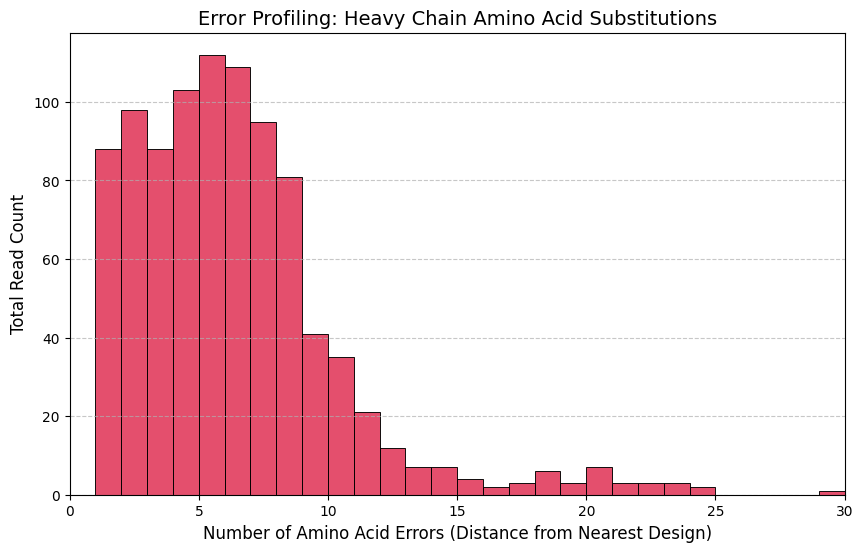

,AA_Errors,read_count,% of Off-Target Reads
0,1,88,9.157128
1,2,98,10.197711
2,3,88,9.157128
3,4,103,10.718002
4,5,112,11.654527
5,6,109,11.342352
6,7,95,9.885536
7,8,81,8.428720
8,9,41,4.266389
9,10,35,3.642040


In [10]:
import Levenshtein
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Isolate the Heavy Chain sequences that were flagged as "Off-target / Error"
# (You can easily swap this to 'Light_Design_Match' later)
off_target_heavy = seq_df[seq_df['Heavy_Design_Match'] == 'Off-target / Error'].copy()

def find_minimum_edit_distance(read_seq, design_list):
    """
    Finds the closest matching design and returns the number of amino acid errors.
    Uses a sliding window to ignore extra adapter sequences on the ends of the read.
    """
    if not isinstance(read_seq, str):
        return None
        
    overall_min_dist = float('inf')
    
    for design in design_list:
        design_len = len(design)
        
        # If the read is weirdly shorter than the design, just do a direct comparison
        if len(read_seq) < design_len:
            dist = Levenshtein.distance(read_seq, design)
            overall_min_dist = min(overall_min_dist, dist)
            continue
            
        # Slide a window the length of the design across the read
        for i in range(len(read_seq) - design_len + 1):
            window = read_seq[i:i+design_len]
            dist = Levenshtein.distance(window, design)
            if dist < overall_min_dist:
                overall_min_dist = dist
                
    return overall_min_dist

# 2. Calculate the minimum errors for all off-target reads (this may take ~5-10 seconds)
print(f"Calculating error profiles for {len(off_target_heavy)} off-target sequences...")
off_target_heavy['AA_Errors'] = off_target_heavy['HAA'].apply(
    lambda x: find_minimum_edit_distance(x, heavy_designs_aa)
)

# 3. Visualize the Error Distribution
plt.figure(figsize=(10, 6))
# We weight the histogram by read_count so highly abundant errors stand out
sns.histplot(
    data=off_target_heavy, 
    x='AA_Errors', 
    weights='read_count',
    bins=range(0, int(off_target_heavy['AA_Errors'].max()) + 2),
    color='crimson'
)

plt.title('Error Profiling: Heavy Chain Amino Acid Substitutions', fontsize=14)
plt.xlabel('Number of Amino Acid Errors (Distance from Nearest Design)', fontsize=12)
plt.ylabel('Total Read Count', fontsize=12)
plt.xlim(0, 30) # Zoom in on the first 30 errors
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 4. Display a concrete summary table
error_summary = off_target_heavy.groupby('AA_Errors')['read_count'].sum().reset_index()
error_summary['% of Off-Target Reads'] = (error_summary['read_count'] / error_summary['read_count'].sum()) * 100
display(error_summary.head(10))

Calculating error profiles for 967 off-target light sequences...


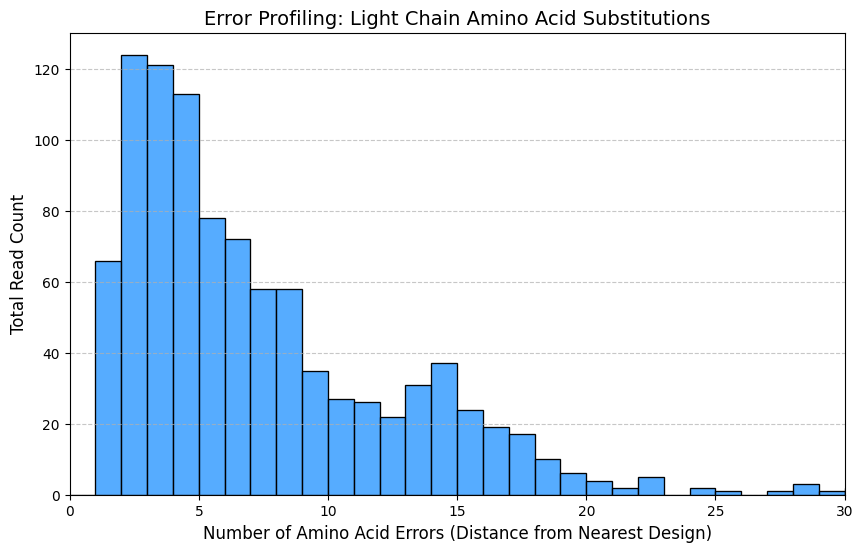

,AA_Errors,read_count,% of Off-Target Reads
0,1,66,6.748466
1,2,124,12.678937
2,3,121,12.372188
3,4,113,11.554192
4,5,78,7.975460
5,6,72,7.361963
6,7,58,5.930470
7,8,58,5.930470
8,9,35,3.578732
9,10,27,2.760736


In [11]:
# 1. Isolate the Light Chain sequences that were flagged as "Off-target / Error"
off_target_light = seq_df[seq_df['Light_Design_Match'] == 'Off-target / Error'].copy()

# 2. Calculate the minimum errors for all off-target reads
print(f"Calculating error profiles for {len(off_target_light)} off-target light sequences...")
off_target_light['AA_Errors'] = off_target_light['LAA'].apply(
    lambda x: find_minimum_edit_distance(x, light_designs_aa)
)

# 3. Visualize the Error Distribution
plt.figure(figsize=(10, 6))
# We use a different color (dodgerblue) to distinguish it from the heavy chain chart
sns.histplot(
    data=off_target_light, 
    x='AA_Errors', 
    weights='read_count',
    bins=range(0, int(off_target_light['AA_Errors'].max(skipna=True)) + 2),
    color='dodgerblue'
)

plt.title('Error Profiling: Light Chain Amino Acid Substitutions', fontsize=14)
plt.xlabel('Number of Amino Acid Errors (Distance from Nearest Design)', fontsize=12)
plt.ylabel('Total Read Count', fontsize=12)
plt.xlim(0, 30) # Zoom in on the first 30 errors
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 4. Display a concrete summary table
error_summary_light = off_target_light.groupby('AA_Errors')['read_count'].sum().reset_index()
error_summary_light['% of Off-Target Reads'] = (error_summary_light['read_count'] / error_summary_light['read_count'].sum()) * 100
display(error_summary_light.head(10))

In [14]:
import pandas as pd

def extract_allowed_mutations(filepath, sheet_name):
    df = pd.read_excel(filepath, sheet_name=sheet_name)
    
    # FIX: The file lists the name twice (Row 1: DNA, Row 2: AA). 
    # We use [0::2] to grab every other row, skipping the duplicates so our blocks are sized correctly.
    all_indices = df[df.iloc[:, 1].notna()].index.tolist()
    design_start_indices = all_indices[0::2] 
    
    library_mutations = {}
    
    for i in range(len(design_start_indices)):
        start_idx = design_start_indices[i]
        # The block ends where the next design begins (or at the end of the file)
        end_idx = design_start_indices[i+1] if i + 1 < len(design_start_indices) else len(df)
        
        design_name = df.iloc[start_idx, 1]
        # Build the Wild-Type AA string
        wt_aa_sequence = "".join(df.iloc[start_idx + 1, 4:].dropna().astype(str))
        
        # Row 4 (relative to start) contains the 'WT' markers
        wt_row_idx = start_idx + 3
        if wt_row_idx >= end_idx: continue
        
        wt_row = df.iloc[wt_row_idx]
        wt_marker_cols = wt_row[wt_row == 'WT'].index.tolist()
        
        allowed_mutations = {} 
        
        # For every CDR loop marked with 'WT'
        for col_name in wt_marker_cols:
            col_idx = df.columns.get_loc(col_name)
            
            offset = 1
            while (col_idx + offset) < len(df.columns):
                if pd.isna(df.iloc[wt_row_idx, col_idx + offset]):
                    break # End of this mutation block
                
                # Calculate the absolute position in the full sequence
                seq_position = (col_idx + offset) - 4 
                
                # Scan the 20 rows beneath (A to Y) to find non-zero probabilities
                allowed_aas = []
                for aa_row_offset in range(5, 25): 
                    aa_label = str(df.iloc[start_idx + aa_row_offset, col_idx]).strip()
                    prob = df.iloc[start_idx + aa_row_offset, col_idx + offset]
                    
                    # Added a safety check to ensure it only reads actual numbers
                    if pd.notna(prob) and isinstance(prob, (int, float)) and prob > 0:
                        allowed_aas.append(aa_label)
                        
                if allowed_aas:
                    allowed_mutations[seq_position] = allowed_aas
                
                offset += 1
                
        library_mutations[design_name] = {
            'wt_sequence': wt_aa_sequence,
            'allowed_mutations': allowed_mutations
        }
        
    return library_mutations

# Parse the heavy chain matrix
heavy_library_rules = extract_allowed_mutations('../AffMat_design.xlsx', 'Heavy Chain Design')

# Print out the rules for the first design to verify
first_design = list(heavy_library_rules.keys())[0]
print(f"--- Allowed Mutations for {first_design} ---")
for pos, aas in heavy_library_rules[first_design]['allowed_mutations'].items():
    wt_aa = heavy_library_rules[first_design]['wt_sequence'][pos]
    print(f"Position {pos} (WT: {wt_aa}): Allowed -> {aas}")

--- Allowed Mutations for IGHV1-18 ---
Position 26 (WT: Y): Allowed -> ['G']
Position 27 (WT: T): Allowed -> ['F', 'Y']
Position 28 (WT: F): Allowed -> ['I', 'N', 'P', 'R', 'S', 'T']
Position 29 (WT: T): Allowed -> ['F', 'L']
Position 30 (WT: S): Allowed -> ['A', 'I', 'N', 'R', 'S', 'T', 'V']
Position 31 (WT: Y): Allowed -> ['D', 'G', 'H', 'N', 'R', 'S', 'T']
Position 32 (WT: G): Allowed -> ['F', 'H', 'S', 'Y']
Position 33 (WT: I): Allowed -> ['A', 'G']
Position 51 (WT: S): Allowed -> ['I', 'T', 'V']
Position 52 (WT: A): Allowed -> ['N', 'R', 'S']
Position 53 (WT: Y): Allowed -> ['A', 'G', 'P', 'S', 'T', 'V']
Position 54 (WT: N): Allowed -> ['D', 'F', 'H', 'N', 'S', 'Y']
Position 55 (WT: G): Allowed -> ['D', 'N', 'S', 'T']
Position 56 (WT: N): Allowed -> ['D', 'G', 'S']
Position 57 (WT: T): Allowed -> ['D', 'E', 'H', 'K', 'N', 'Y']
Position 58 (WT: N): Allowed -> ['A', 'R', 'T']


In [15]:
print(heavy_library_rules.keys())

dict_keys(['IGHV1-18', 'IGHV1-46', 'IGHV1-69', 'IGHV3-7', 'IGHV3-15', 'IGHV3-23', 'IGHV3-30', 'IGHV4-39', 'IGHV4-59', 'IGHV5-51'])


Scoring heavy chain reads against the positional weight matrix...


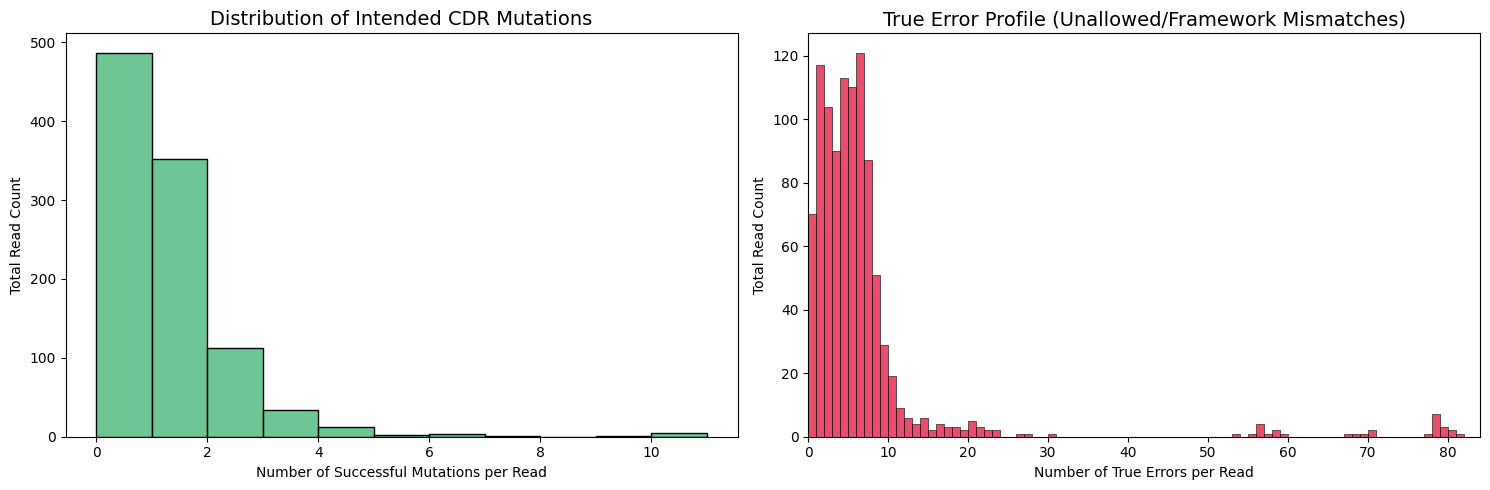

--- Heavy Chain Library Composition ---


,True_Heavy_Design,read_count
0,IGHV5-51,240
1,IGHV1-69,154
2,IGHV1-18,132
3,IGHV1-46,130
4,IGHV3-30,85
5,IGHV3-23,83
6,IGHV4-59,61
7,IGHV3-7,56
8,IGHV4-39,30
9,IGHV3-15,24


In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def score_library_read(read_seq, rules_dict):
    """
    Slides a read against all library designs. Categorizes mismatches into
    intended CDR mutations vs true errors. Returns the best matching design.
    """
    if not isinstance(read_seq, str):
        return pd.Series(["No sequence", 0, None])
        
    best_design = "Unknown"
    min_errors = float('inf')
    associated_intended = 0
    
    # Test the read against every design in our dictionary
    for design_name, rules in rules_dict.items():
        wt_seq = rules['wt_sequence']
        allowed_muts = rules['allowed_mutations']
        design_len = len(wt_seq)
        
        if len(read_seq) < design_len:
            continue
            
        # Slide a window across the read to handle extra adapter bases on the ends
        for i in range(len(read_seq) - design_len + 1):
            window = read_seq[i:i+design_len]
            intended = 0
            errors = 0
            
            for pos in range(design_len):
                if window[pos] != wt_seq[pos]:
                    # Check if this mismatch was explicitly allowed in the Excel file
                    if pos in allowed_muts and window[pos] in allowed_muts[pos]:
                        intended += 1
                    else:
                        errors += 1
            
            # We want the alignment that minimizes TRUE errors
            if errors < min_errors:
                min_errors = errors
                associated_intended = intended
                best_design = design_name
    
    # FIX: Handle cases where the sequence was too short to align anywhere
    if min_errors == float('inf'):
        return pd.Series(["Un-alignable", 0, None])
                
    return pd.Series([best_design, associated_intended, min_errors])

print("Scoring heavy chain reads against the positional weight matrix...")
seq_df[['True_Heavy_Design', 'Intended_Mutations', 'True_Errors']] = seq_df['HAA'].apply(
    lambda x: score_library_read(x, heavy_library_rules)
)

# Visualize the true library quality
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Intended Mutations (The Successes)
sns.histplot(data=seq_df, x='Intended_Mutations', weights='read_count', 
             bins=range(0, int(seq_df['Intended_Mutations'].max(skipna=True)) + 2), 
             color='mediumseagreen', ax=axes[0])
axes[0].set_title('Distribution of Intended CDR Mutations', fontsize=14)
axes[0].set_xlabel('Number of Successful Mutations per Read')
axes[0].set_ylabel('Total Read Count')

# Plot 2: True Errors (The Failures)
# FIX: Use skipna=True to ignore the 'None' values we assigned to un-alignable sequences
max_errors = seq_df['True_Errors'].max(skipna=True)
max_errors = 0 if pd.isna(max_errors) else int(max_errors)

sns.histplot(data=seq_df, x='True_Errors', weights='read_count', 
             bins=range(0, max_errors + 2), 
             color='crimson', ax=axes[1])
axes[1].set_title('True Error Profile (Unallowed/Framework Mismatches)', fontsize=14)
axes[1].set_xlabel('Number of True Errors per Read')
axes[1].set_ylabel('Total Read Count')
axes[1].set_xlim(0, max(20, max_errors))

plt.tight_layout()
plt.show()

# Display a summary of the best performing designs
print("--- Heavy Chain Library Composition ---")
display(seq_df.groupby('True_Heavy_Design')['read_count'].sum().sort_values(ascending=False).reset_index())

In [18]:
# Filter for reads with exactly 6 true errors (you can change this number)
sample_reads = seq_df[seq_df['True_Errors'] == 6].head(3)

print(f"--- Highlighting True Errors for {len(sample_reads)} Sample Reads ---\n")

for idx, row in sample_reads.iterrows():
    read_seq = row['HAA']
    design_name = row['True_Heavy_Design']
    
    # Get rules and WT sequence
    rules = heavy_library_rules[design_name]
    wt_seq = rules['wt_sequence']
    allowed_muts = rules['allowed_mutations']
    design_len = len(wt_seq)
    
    best_window = ""
    min_errors = float('inf')
    best_start_idx = 0
    
    # Re-run sliding window to find the exact alignment match
    for i in range(len(read_seq) - design_len + 1):
        window = read_seq[i:i+design_len]
        errors = 0
        for pos in range(design_len):
            if window[pos] != wt_seq[pos]:
                if not (pos in allowed_muts and window[pos] in allowed_muts[pos]):
                    errors += 1
        
        if errors < min_errors:
            min_errors = errors
            best_window = window
            best_start_idx = i
            
    # Generate visual alignment strings
    match_str = ""
    for pos in range(design_len):
        if best_window[pos] == wt_seq[pos]:
            match_str += "|" # Perfect match
        elif pos in allowed_muts and best_window[pos] in allowed_muts[pos]:
            match_str += ":" # Intended mutation
        else:
            match_str += "X" # True Error
            
    print(f"Design: {design_name}")
    print(f"Offset: Read has {best_start_idx} extra N-term AAs and {len(read_seq) - design_len - best_start_idx} extra C-term AAs.")
    print(f"WT:    {wt_seq}")
    print(f"Match: {match_str}")
    print(f"Read:  {best_window}\n")

--- Highlighting True Errors for 3 Sample Reads ---

Design: IGHV4-59
Offset: Read has 0 extra N-term AAs and 27 extra C-term AAs.
WT:    EVQLQESGPGLVKPSETLSLTCTVSGGSISSYYWSWIRQPPGKGLEWIGYIYYSGSTNYNPSLKSRVTISVDTSKNQFSLKLSSVTAADTAVYYC
Match: |XX|||||||||||||||||||||||||X|:|||||||||||||||||||XX:|||X||||||||||||||||||||||||||||||||||||||
Read:  ELELQESGPGLVKPSETLSLTCTVSGGSMSRYYWSWIRQPPGKGLEWIGYVSSSGSANYNPSLKSRVTISVDTSKNQFSLKLSSVTAADTAVYYC

Design: IGHV4-59
Offset: Read has 0 extra N-term AAs and 29 extra C-term AAs.
WT:    EVQLQESGPGLVKPSETLSLTCTVSGGSISSYYWSWIRQPPGKGLEWIGYIYYSGSTNYNPSLKSRVTISVDTSKNQFSLKLSSVTAADTAVYYC
Match: |X|||X||||||||||||||X||||||||X:|:||||X||||||||||||X||||||||||||||||||||||||||||||||||||||||||||
Read:  ELQLQDSGPGLVKPSETLSLSCTVSGGSITRYFWSWIGQPPGKGLEWIGYVYYSGSTNYNPSLKSRVTISVDTSKNQFSLKLSSVTAADTAVYYC

Design: IGHV4-59
Offset: Read has 0 extra N-term AAs and 27 extra C-term AAs.
WT:    EVQLQESGPGLVKPSETLSLTCTVSGGSISSYYWSWIRQPPGKGLEWIGYIYYSGSTNYNPSLKSRVTISVDTSKNQFSLKLSSVT

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.enum.text import PP_ALIGN

# 1. Regenerate and save the high-resolution visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data=seq_df, x='Intended_Mutations', weights='read_count', 
             bins=range(0, int(seq_df['Intended_Mutations'].max(skipna=True)) + 2), 
             color='mediumseagreen', ax=axes[0])
axes[0].set_title('Distribution of Intended CDR Mutations', fontsize=14)
axes[0].set_xlabel('Number of Successful Mutations per Read')
axes[0].set_ylabel('Total Read Count')

max_errors = seq_df['True_Errors'].max(skipna=True)
max_errors = 0 if pd.isna(max_errors) else int(max_errors)

sns.histplot(data=seq_df, x='True_Errors', weights='read_count', 
             bins=range(0, max_errors + 2), 
             color='crimson', ax=axes[1])
axes[1].set_title('True Error Profile (Unallowed/Framework Mismatches)', fontsize=14)
axes[1].set_xlabel('Number of True Errors per Read')
axes[1].set_ylabel('Total Read Count')
axes[1].set_xlim(0, max(20, max_errors))

plt.tight_layout()
image_path = 'heavy_chain_distributions.png'
plt.savefig(image_path, dpi=300, bbox_inches='tight')
plt.close() # Close the plot so it doesn't duplicate in the notebook output

# 2. Initialize the PowerPoint Presentation
prs = Presentation()

# Slide 1: Title Slide
title_slide_layout = prs.slide_layouts[0]
slide1 = prs.slides.add_slide(title_slide_layout)
title = slide1.shapes.title
subtitle = slide1.placeholders[1]
title.text = "Antibody Library QC Analysis"
subtitle.text = "Heavy Chain Affinity Maturation Workflow & Biological Quality Control"

# Slide 2: Computational Workflow
bullet_slide_layout = prs.slide_layouts[1]
slide2 = prs.slides.add_slide(bullet_slide_layout)
slide2.shapes.title.text = "Computational Pipeline Overview"
tf2 = slide2.shapes.placeholders[1].text_frame
tf2.text = "Data Ingestion: Parsed complex Positional Weight Matrices (PWM) from library Excel designs to extract allowed combinatorial frequencies."
p = tf2.add_paragraph()
p.text = "Smart Alignment: Implemented a sliding-window algorithm to map sequencing reads against wild-type scaffolds, naturally handling untrimmed C-terminal adapter sequences."
p = tf2.add_paragraph()
p.text = "Error Categorization: Functionally differentiated intended CDR combinatorial mutations from true physical synthesis errors."
p = tf2.add_paragraph()
p.text = "Biological QC: Generated visual alignments to map specific off-target error locations, identifying systematic primer scars vs. baseline synthesis noise."

# Slide 3: Visual Results
title_only_layout = prs.slide_layouts[5]
slide3 = prs.slides.add_slide(title_only_layout)
slide3.shapes.title.text = "Heavy Chain Mutagenesis & Error Profiles"
# Insert the saved seaborn plot
slide3.shapes.add_picture(image_path, Inches(0.5), Inches(2), width=Inches(9))

# Slide 4: Key Findings & Conclusions
slide4 = prs.slides.add_slide(bullet_slide_layout)
slide4.shapes.title.text = "Key Findings & Conclusions"
tf4 = slide4.shapes.placeholders[1].text_frame

p = tf4.add_paragraph()
p.text = "Library Representation is Complete: All 10 heavy chain designs are physically present in the sequencing data without catastrophic dropouts."
p.level = 0

p = tf4.add_paragraph()
p.text = "Successful Mutagenesis Limits: The library successfully incorporated up to 11 intended CDR mutations per read in the highest-diversity subset."
p.level = 0

p = tf4.add_paragraph()
p.text = "Wild-Type Bias: The dominant population of the library reverted to or remained wild-type (0-1 intended mutations), indicating low overall mutagenesis efficiency."
p.level = 0

p = tf4.add_paragraph()
p.text = "Systematic Cloning Scar Identified: A highly consistent N-terminal primer mismatch (e.g., ELEL vs EVQL) was identified, accounting for the artificial baseline of 4-8 'True Errors' per sequence."
p.level = 0

# Save the presentation
pptx_filename = 'Library_QC_Summary.pptx'
prs.save(pptx_filename)
print(f"Executive summary successfully generated and saved to {pptx_filename}!")

Executive summary successfully generated and saved to Library_QC_Summary.pptx!


Scoring light chain reads against the positional weight matrix...


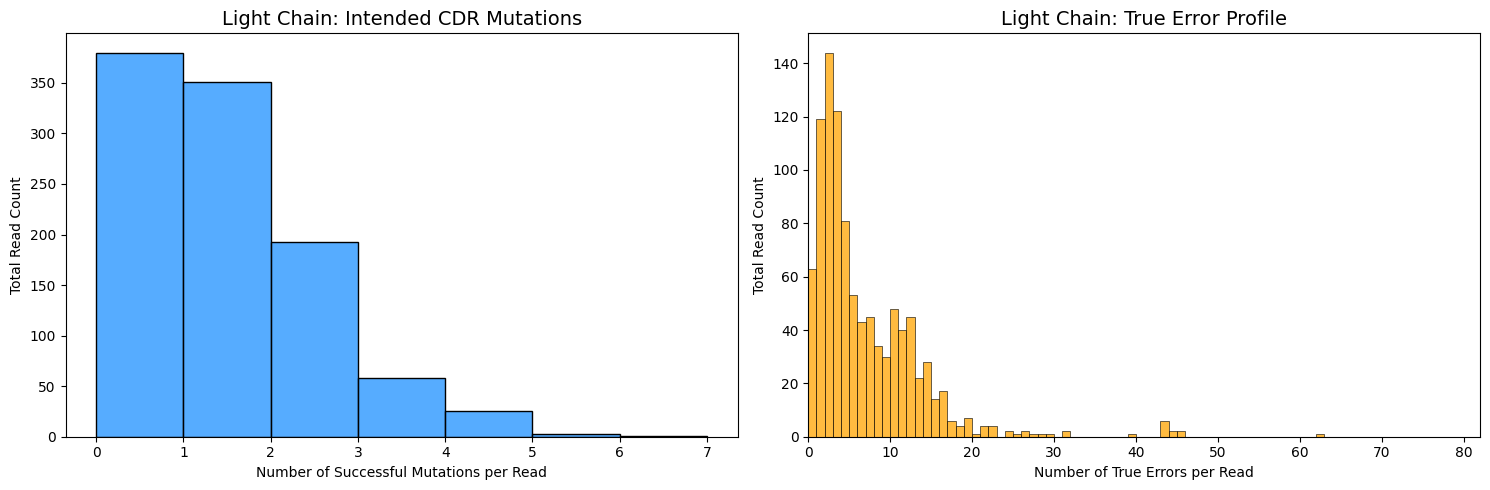

--- Light Chain Library Composition ---


,True_Light_Design,read_count
0,IGKV3-20,228
1,IGKV3-15,176
2,IGKV1-39,125
3,IGKV2-28,116
4,IGKV4-1,105
5,IGLV1-40,66
6,IGLV2-14,57
7,IGLV2-23,51
8,IGLV1-44,37
9,IGLV1-51,28



Generating complete PowerPoint presentation...
Presentation successfully generated and saved to Complete_Library_QC_Summary.pptx!


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pptx import Presentation
from pptx.util import Inches

# 1. Parse Light Chain Rules & Score Reads
light_library_rules = extract_allowed_mutations('../AffMat_design.xlsx', 'Light Chain Design')

print("Scoring light chain reads against the positional weight matrix...")
seq_df[['True_Light_Design', 'LC_Intended_Mutations', 'LC_True_Errors']] = seq_df['LAA'].apply(
    lambda x: score_library_read(x, light_library_rules)
)

# 2. Generate and Save Light Chain Visualizations
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Light Chain Intended Mutations
sns.histplot(data=seq_df, x='LC_Intended_Mutations', weights='read_count', 
             bins=range(0, int(seq_df['LC_Intended_Mutations'].max(skipna=True)) + 2), 
             color='dodgerblue', ax=axes[0])
axes[0].set_title('Light Chain: Intended CDR Mutations', fontsize=14)
axes[0].set_xlabel('Number of Successful Mutations per Read')
axes[0].set_ylabel('Total Read Count')

# Plot 2: Light Chain True Errors
lc_max_errors = seq_df['LC_True_Errors'].max(skipna=True)
lc_max_errors = 0 if pd.isna(lc_max_errors) else int(lc_max_errors)

sns.histplot(data=seq_df, x='LC_True_Errors', weights='read_count', 
             bins=range(0, lc_max_errors + 2), 
             color='orange', ax=axes[1])
axes[1].set_title('Light Chain: True Error Profile', fontsize=14)
axes[1].set_xlabel('Number of True Errors per Read')
axes[1].set_ylabel('Total Read Count')
axes[1].set_xlim(0, max(20, lc_max_errors))

plt.tight_layout()
lc_image_path = 'light_chain_distributions.png'
plt.savefig(lc_image_path, dpi=300, bbox_inches='tight')
plt.show()

print("--- Light Chain Library Composition ---")
display(seq_df.groupby('True_Light_Design')['read_count'].sum().sort_values(ascending=False).reset_index())

# 3. Generate the Complete PowerPoint Presentation
print("\nGenerating complete PowerPoint presentation...")
prs = Presentation()

# Slide 1: Title
title_slide_layout = prs.slide_layouts[0]
slide1 = prs.slides.add_slide(title_slide_layout)
slide1.shapes.title.text = "Antibody Library QC Analysis"
slide1.placeholders[1].text = "Heavy & Light Chain Affinity Maturation Workflow & Quality Control"

# Slide 2: Pipeline
bullet_slide_layout = prs.slide_layouts[1]
slide2 = prs.slides.add_slide(bullet_slide_layout)
slide2.shapes.title.text = "Computational Pipeline Overview"
tf2 = slide2.shapes.placeholders[1].text_frame
tf2.text = "Data Ingestion: Parsed complex Positional Weight Matrices (PWM) from library Excel designs to extract allowed combinatorial frequencies."
tf2.add_paragraph().text = "Smart Alignment: Implemented a sliding-window algorithm to map sequencing reads against wild-type scaffolds, handling untrimmed C-terminal adapters."
tf2.add_paragraph().text = "Error Categorization: Functionally differentiated intended CDR combinatorial mutations from true physical synthesis errors."
tf2.add_paragraph().text = "Biological QC: Generated visual alignments to map specific off-target error locations across both heavy and light chains."

# Slide 3: Heavy Chain Visuals
title_only_layout = prs.slide_layouts[5]
slide3 = prs.slides.add_slide(title_only_layout)
slide3.shapes.title.text = "Heavy Chain Mutagenesis & Error Profiles"
# Uses the image we saved in the previous step
slide3.shapes.add_picture('heavy_chain_distributions.png', Inches(0.5), Inches(2), width=Inches(9))

# Slide 4: Light Chain Visuals
slide4 = prs.slides.add_slide(title_only_layout)
slide4.shapes.title.text = "Light Chain Mutagenesis & Error Profiles"
# Uses the new light chain image
slide4.shapes.add_picture(lc_image_path, Inches(0.5), Inches(2), width=Inches(9))

# Slide 5: Key Findings
slide5 = prs.slides.add_slide(bullet_slide_layout)
slide5.shapes.title.text = "Key Findings & Conclusions"
tf5 = slide5.shapes.placeholders[1].text_frame
tf5.text = "Library Representation: Both heavy and light chain designs are physically present in the sequencing data without catastrophic dropouts."
tf5.add_paragraph().text = "Mutagenesis Efficiency: The library successfully incorporated intended CDR mutations, though the dominant populations remain skewed toward the wild-type framework (0-1 intended mutations)."
tf5.add_paragraph().text = "Heavy Chain Scarring: A consistent N-terminal primer mismatch (e.g., ELEL vs EVQL) was identified in the heavy chain reads, creating an artificial baseline of 4-8 true errors."
tf5.add_paragraph().text = "Light Chain Integrity: Light chain errors largely follow expected baseline synthesis noise without the severe systematic primer scarring seen in the heavy chain."

pptx_filename = 'Complete_Library_QC_Summary.pptx'
prs.save(pptx_filename)
print(f"Presentation successfully generated and saved to {pptx_filename}!")